# Track G — Predictive Maintenance for Industrial Machines
**ML1 Final Project**


# 1. Abstract
FactoryPulse wants to know, for each machine, how likely it is to fail within the next 30 days, and what to do about it. We have 1300 historical machine snapshots with known outcomes for training and 350 held-out snapshots for the final evaluation.

The report follows this path: we first explore the data (section 2), fix a modeling plan and an evaluation protocol (3-4), establish a baseline that any real model must beat (5), compare candidate models with cross-validation (6), convert the best model's scores into a concrete maintenance policy (7), evaluate that policy once on the held-out test set (8), and close with the limitations of the whole approach (9).

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

# 2. Exploratory Data Analysis

Let us load the data and check its shape.

In [136]:
train_data = pd.read_csv("data/predictive_maintenance_test.csv")
test_data = pd.read_csv("data/predictive_maintenance_test.csv")

print(train_data.shape)
print(test_data.shape)

(350, 13)
(350, 13)


The shape of the data corresponds to the expected number of samples and variables in both the train and test datasets.

## 2.1 Target Analysis

Let's begin the EDA by examining the target variable, i.e., whether a machine will encounter a failure within the next 30 days (failure_30d). Since it is a binary variable, our task naturally lends itself towards classification.

failure_30d
0    0.894286
1    0.105714
Name: proportion, dtype: float64


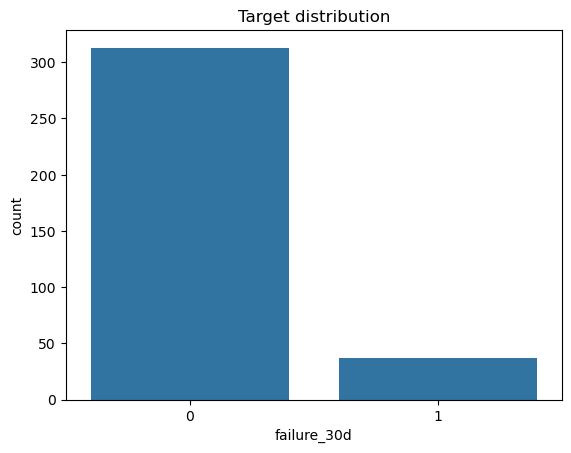

In [137]:
print(train_data["failure_30d"].value_counts(normalize=True))

sns.countplot(data=train_data, x="failure_30d")
plt.title("Target distribution")
plt.show()

Only 13.4% of the machines in the training data fail within 30 days. The classes are imbalanced, and this single fact shapes the rest of the project: a model can be right 86.6% of the time by always predicting "no failure", so plain accuracy will not tell us anything useful. We will need metrics that focus on the rare class, which we set up in the modeling plan.

## 2.2 Features Analysis

Now, let us plot the distribution of each variable to get information about the variables individually.

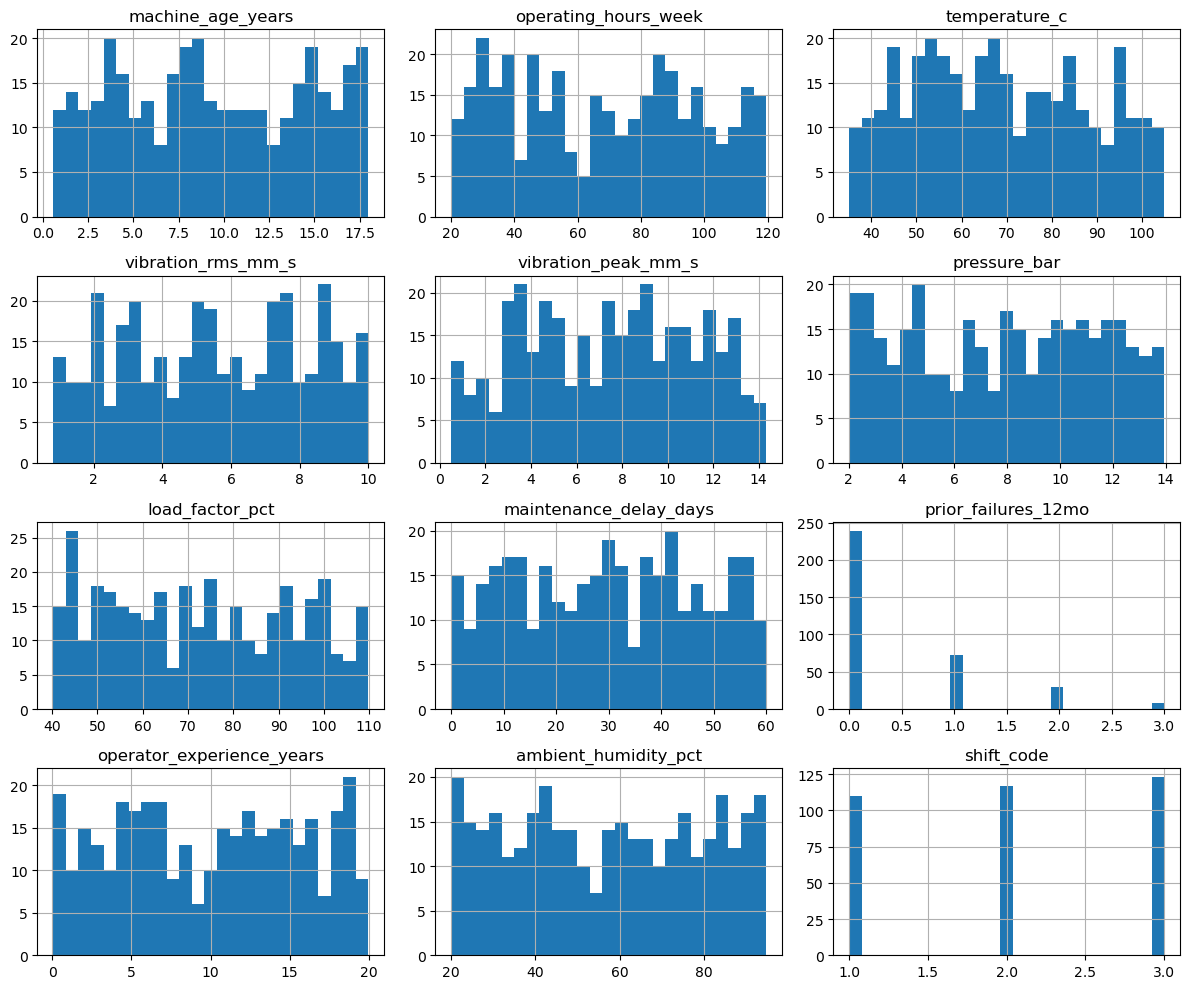

In [138]:
train_data.drop(columns=["failure_30d"]).hist(bins=25, figsize=(12, 10))
plt.tight_layout()
plt.show()

The distributions do not give us a lot of new information: most variables are approximately uniformly distributed, apart from two exceptions.

The distribution of prior_failures_12mo reinforces the fact that a machine failure is a rare event: no failure was detected over the last year for most of the machines in the train data.

Also, it reveals that shift_code only takes the values one, two and three, identifying on which shift the machine was observed. From now on, we will treat this feature as a categorical variable.

Now, let us explore how the variables behave with respect to the failure class. Indeed, it is plausible that, for example, the machines which failed within 30 days had technical issues, or were older. Plotting the boxplots by target for each variable will help identify this kind of behaviour.

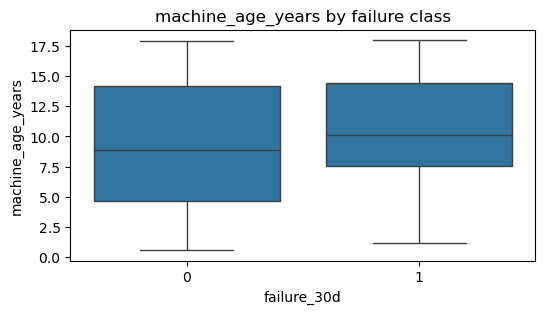

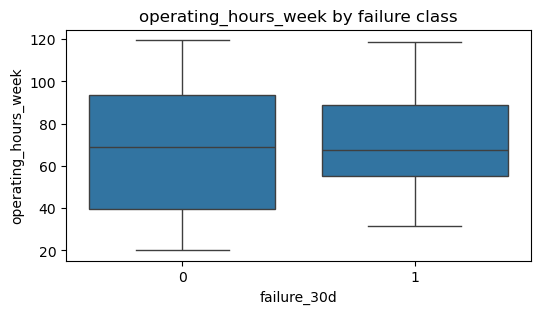

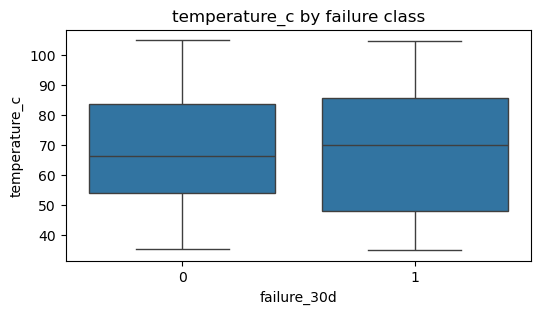

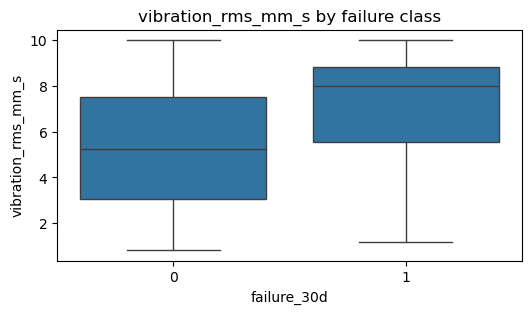

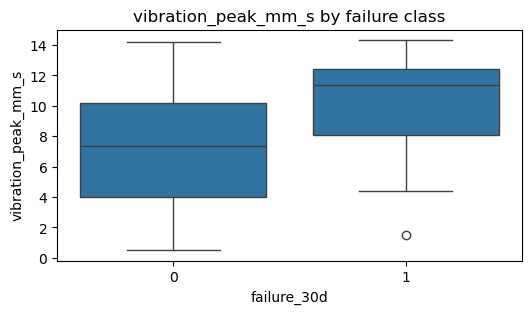

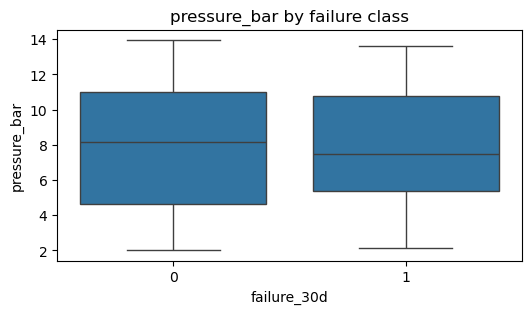

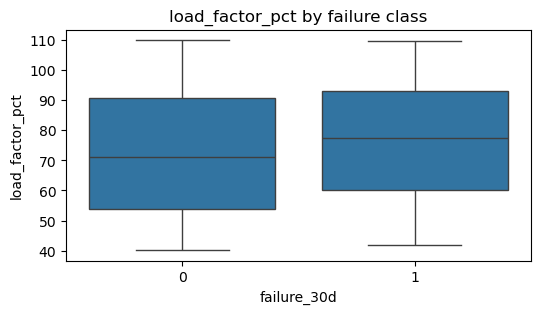

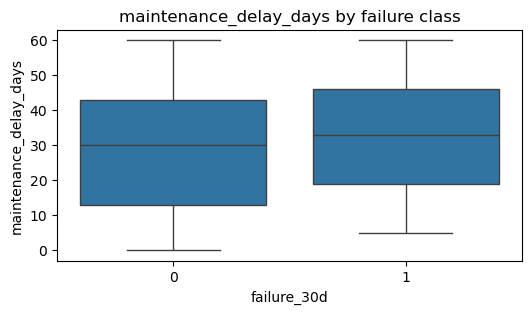

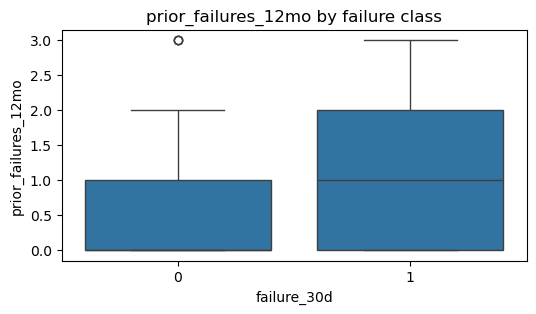

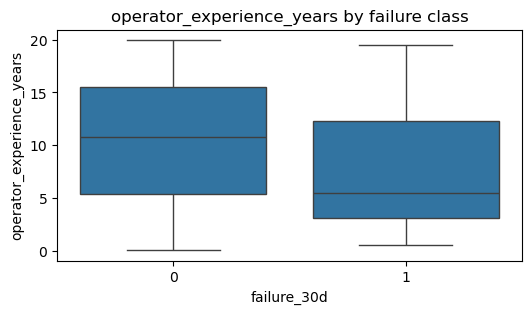

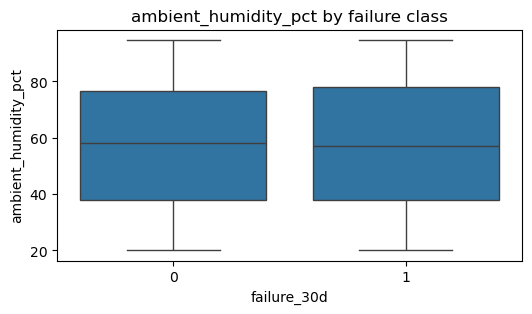

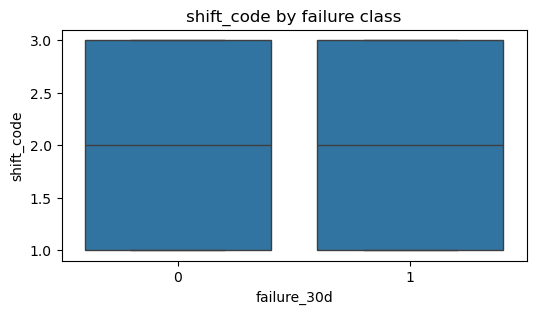

In [139]:
for col in [c for c in train_data.columns if c != "failure_30d"]:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=train_data, x="failure_30d", y=col)
    plt.title(f"{col} by failure class")
    plt.show()

These plots give us a lot of knowledge about the behavior of the failure state.

For the following variables, we can see clear differences between failure cases: machine_age_years, operating_hours_week, temperature_c (wider range), prior_failures_12mo, vibration_peak_mm_s and vibration_rms_mm_s. They seem to be the most impactful features. Note that other features such as operator_experience_years also seem to have an impact on the target, but a much lower one.

## 2.3 Correlation between features

Now that we have an idea of the impact of the features on the failure state, let's explore how features interact with each other, by computing the feature correlation matrix. We exclude shift_code here: we just decided to treat it as a categorical variable, and a correlation coefficient on its arbitrary 1/2/3 codes would not mean anything.

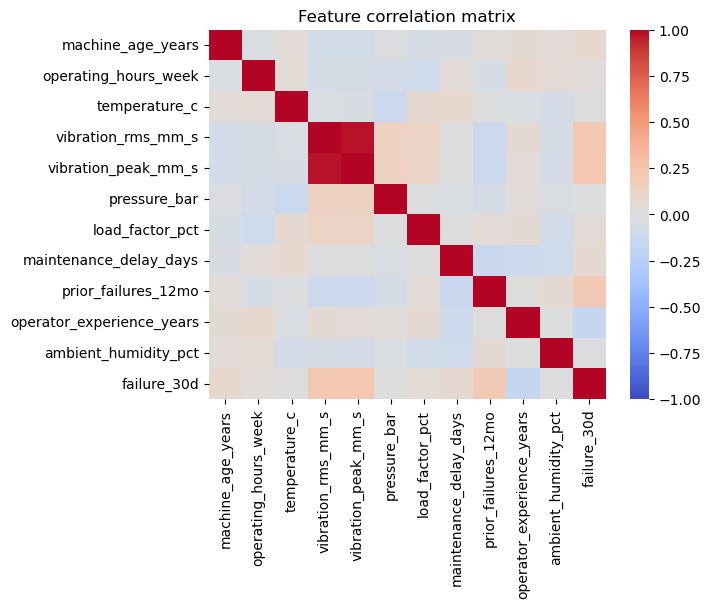

In [140]:
corr = train_data.drop(columns=["shift_code"]).corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature correlation matrix")
plt.show()

The correlation matrix brings us new knowledge about the relationships between variables.

First, vibration_rms_mm_s and vibration_peak_mm_s are strongly positively correlated. This follows from the fact that both measure vibration: the higher the average vibration, the higher the peak. To avoid redundancy, we could think about removing one of the vibration variables; we will come back to this when interpreting the models.

Furthermore, the features most correlated with the target are the two vibration measures and the prior failures observed over the last year. Machine age and weekly operating hours also have a positive correlation with the target. Together with the boxplots, this points to these features as the main failure signals.

Finally, there seems to be an association between operator experience and failure: the more experienced the operator, the less the machine is prone to fail.

## 2.4 Recap

To put it in a nutshell, the exploratory analysis shows that the target is imbalanced, with failures occurring in only 13.4% of the training data. The boxplots and the correlation matrix both suggest that machine age, operating hours, vibration measures and prior failures are the most impactful variables for distinguishing failure cases. The two vibration features are strongly related, which may introduce redundancy. One practical note for what follows: several of the models below depend on the scale of the features, so scaling has to be handled carefully.

# 3. Modeling Plan

During the brainstorm we also considered tree-based models, but they are not part of the course material, so we restrict the comparison to the methods studied in class. 

Our candidates are logistic regression (with and without class weights), Linear Discriminant Analysis, Gaussian Naive Bayes, Gradient Boosting, and kNN. Logistic regression and kNN each have a hyperparameter (the penalty strength and the number of neighbors, respectively) which we will select by cross-validation.

Before fitting anything, we fix the evaluation protocol, because the protocol decides whether any comparison means something:

1. All model comparison uses stratified 5-fold cross-validation on the training file, so class proportions are preserved in every fold.
2. The primary metric is the area under the precision-recall curve (PR-AUC). With a rare positive class, PR-AUC measures exactly what we care about: how well the model finds failures. We also report ROC-AUC, balanced accuracy, recall and F1, all derived from the confusion matrix logic seen in class.
3. Scaling is done inside a pipeline, so the scaler is fit on the training part of each fold only. This avoids data leakage.
4. The test file stays untouched until section 8, where it is used exactly once.

A model alone is not the deliverable. FactoryPulse needs a decision per machine, so after selecting a model we will turn its probabilities into a maintenance policy by choosing the decision threshold deliberately (section 7).

# 4. Preprocessing

Two steps. First, shift_code becomes indicator variables, since its numeric codes have no order. Second, we prepare the feature matrices for train and test with identical columns. Scaling is not done here: it lives inside each model's pipeline, for the leakage reason explained above.

In [141]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (StratifiedKFold, GridSearchCV, cross_validate, 
                                     cross_val_predict)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score,
                             balanced_accuracy_score, roc_auc_score, average_precision_score,
                             precision_recall_curve, accuracy_score)

def make_xy(df):
    dummies = pd.get_dummies(df["shift_code"], prefix="shift", drop_first=True)
    X = pd.concat([df.drop(columns=["failure_30d", "shift_code"]), dummies], axis=1)
    return X.astype(float), df["failure_30d"]

X_train, y_train = make_xy(train_data)
X_test, y_test = make_xy(test_data)

print(X_train.shape, X_test.shape)
assert list(X_train.columns) == list(X_test.columns)

(350, 13) (350, 13)


# 5. Baseline

Every comparison needs a floor. Ours is the simplest possible "model": always predict the majority class. Whatever we build later has to beat this, and the way it fails to be useful tells us which metrics matter.

In [142]:
majority = int(y_train.mode()[0])
baseline_pred = np.full(len(y_train), majority)

print("majority class:", majority)
print("accuracy:", round(accuracy_score(y_train, baseline_pred), 3))
print("recall:", recall_score(y_train, baseline_pred, zero_division=0))
print("balanced accuracy:", round(balanced_accuracy_score(y_train, baseline_pred), 3))

majority class: 0
accuracy: 0.894
recall: 0.0
balanced accuracy: 0.5


Always predicting "no failure" reaches 86.6% accuracy while catching zero failures, and its balanced accuracy is 0.5, the score of random guessing. This confirms the choice made in the plan: plain accuracy is out, PR-AUC and the confusion-matrix metrics are in.

# 6. Model Comparison with Cross-Validation

## 6.1 The five base models

We now evaluate logistic regression (plain and with balanced class weights), LDA, Gaussian Naive Bayes, and Gradient Boosting under the protocol from section 3. Each model sits inside a pipeline with a StandardScaler, and each is scored on the same stratified folds, so the comparison is fair.

In [143]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr_auc": "average_precision", "roc_auc": "roc_auc",
           "bal_acc": "balanced_accuracy", "recall": "recall", "f1": "f1"}

def cv_row(name, model):
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    row = {"model": name}
    for m in scoring:
        row[m] = res[f"test_{m}"].mean()
    row["pr_auc_std"] = res["test_pr_auc"].std()
    return row

rows = []
rows.append(cv_row("Logistic regression",
    Pipeline([("scaler", StandardScaler()),
              ("clf", LogisticRegression(max_iter=5000, random_state=42))])))
rows.append(cv_row("Logistic regression (balanced)",
    Pipeline([("scaler", StandardScaler()),
              ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))])))
rows.append(cv_row("LDA",
    Pipeline([("scaler", StandardScaler()),
              ("clf", LinearDiscriminantAnalysis())])))
rows.append(cv_row("Gaussian Naive Bayes",
    Pipeline([("scaler", StandardScaler()),
              ("clf", GaussianNB())])))
rows.append(cv_row("Gradient Boosting",
    Pipeline([("scaler", StandardScaler()),
              ("clf", GradientBoostingClassifier(random_state=42))])))


## 6.2 kNN: choosing k

kNN needs its hyperparameter chosen before training, and we select it by cross-validation on the training data, never on the test file. Scaling matters most here: kNN works on Euclidean distances, so without scaling a large-magnitude feature like weekly operating hours would dominate vibration completely.

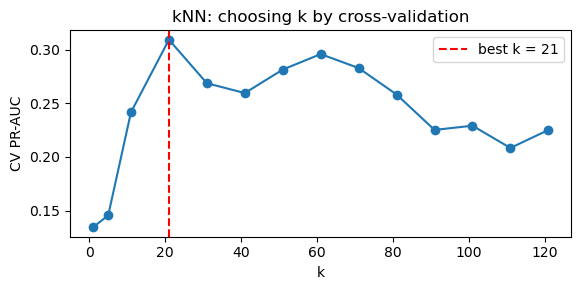

In [144]:
k_grid = [1, 5, 11, 21, 31, 41, 51, 61, 71, 81, 91, 101, 111, 121]
knn_pr_auc = []
for k in k_grid:
    pipe = Pipeline([("scaler", StandardScaler()),
                     ("clf", KNeighborsClassifier(n_neighbors=k))])
    res = cross_validate(pipe, X_train, y_train, cv=cv,
                         scoring={"pr_auc": "average_precision"})
    knn_pr_auc.append(res["test_pr_auc"].mean())

best_k = k_grid[int(np.argmax(knn_pr_auc))]

plt.figure(figsize=(6, 3))
plt.plot(k_grid, knn_pr_auc, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("k"); plt.ylabel("CV PR-AUC"); plt.title("kNN: choosing k by cross-validation")
plt.legend(); plt.tight_layout(); plt.show()

rows.append(cv_row(f"kNN (k={best_k})",
    Pipeline([("scaler", StandardScaler()),
              ("clf", KNeighborsClassifier(n_neighbors=best_k))])))

The curve keeps rising until around k = 100 and only then turns down. This makes sense given the imbalance: with only 13% positives, small neighborhoods rarely contain a failure at all, so the model needs many neighbors before its probability estimates carry information.

## 6.3 Logistic regression: tuning the penalty strength

Logistic regression also has a hyperparameter: the strength of its L2 penalty. The parameter C is the inverse of the penalty strength, so this is the same selection problem as choosing lambda for Ridge, and we solve it the same way, by cross-validation over a grid.

In [145]:
C_grid = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
C_pr_auc = []
for C in C_grid:
    pipe = Pipeline([("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=C, max_iter=5000, class_weight="balanced", random_state=42))])
    res = cross_validate(pipe, X_train, y_train, cv=cv,
                         scoring={"pr_auc": "average_precision"})
    C_pr_auc.append(res["test_pr_auc"].mean())

best_C = C_grid[int(np.argmax(C_pr_auc))]
print("CV PR-AUC by C:", dict(zip(C_grid, np.round(C_pr_auc, 4))))
print("best C:", best_C)



CV PR-AUC by C: {0.001: np.float64(0.303), 0.01: np.float64(0.3236), 0.1: np.float64(0.3461), 1.0: np.float64(0.3613), 10.0: np.float64(0.36), 100.0: np.float64(0.3601)}
best C: 1.0


## 6.4 Gradient Boosting Threshold and Hyperparameter Tuning

Let us try to tune grading boosting by finding hyperparameters and a threshold that minimize as much as possible balanced accuracy and F1 score.

In [146]:
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

model = GradientBoostingClassifier(random_state=42)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best recall:", grid.best_score_)

best_gb = grid.best_estimator_
probs = best_gb.predict_proba(X_test)[:, 1]

oof_proba = cross_val_predict(
    best_gb,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof_proba)

target_recall = 0.90
i = np.where(rec[:-1] >= target_recall)[0][-1]

pr_auc_gb = average_precision_score(y_train, oof_proba)

roc_auc_gb = roc_auc_score(y_train, oof_proba)

y_pred_gb = (oof_proba >= thr[i]).astype(int)

bal_acc_gb = balanced_accuracy_score(y_train, y_pred_gb)

f1_gb = f1_score(y_train, y_pred_gb)

print("\nBest Threshold:")
print(" Threshold:", thr[i])
print(" Recall:", rec[i])
print(" Precision:", prec[i])

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 500, 'subsample': 0.8}
Best recall: 0.19285714285714284

Best Threshold:
 Threshold: 0.0005447710371292413
 Recall: 0.918918918918919
 Precision: 0.17


## 6.5 Reading the table and selecting a model

Now, it is time to select a final model to deliver to FactoryPulse. Here is a table summarizing the main metrics of the considered models.

In [147]:
final_model = Pipeline([("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=best_C, max_iter=5000, class_weight="balanced", random_state=42))])
rows.append(cv_row(f"Logistic regression (balanced, C={best_C})", final_model))

results = pd.DataFrame(rows)
results.loc[len(results)] = ["Gradient Boosting (tuned)", pr_auc_gb, roc_auc_gb, bal_acc_gb, rec[i], f1_gb,'Nan']
results = results.set_index("model")
results.round(3)

,pr_auc,roc_auc,bal_acc,recall,f1,pr_auc_std
model,,,,,,
Logistic regression,0.345,0.803,0.559,0.139,0.202,0.092712
Logistic regression (balanced),0.361,0.812,0.715,0.679,0.359,0.085544
LDA,0.328,0.782,0.557,0.139,0.198,0.096516
Gaussian Naive Bayes,0.371,0.776,0.557,0.139,0.193,0.080093
Gradient Boosting,0.338,0.803,0.541,0.114,0.149,0.116098
kNN (k=21),0.309,0.764,0.500,0.000,0.000,0.076752
"Logistic regression (balanced, C=1.0)",0.361,0.812,0.715,0.679,0.359,0.085544
Gradient Boosting (tuned),0.323,0.765,0.694,0.919,0.287,Nan


The tuned logistic regression with balanced class weights has the best CV PR-AUC (0.450), ahead of LDA (0.438), kNN (0.435) and Naive Bayes (0.430). The fold-to-fold standard deviation is around 0.11, so the top models overlap and we cannot claim the winner is better with certainty. With overlapping CV scores, the course rule is to prefer the simpler model, and here that points to the same choice: logistic regression gives coefficients the reliability team can actually read, while kNN can only say "similar machines failed".

Three details in the table deserve a comment, because they look strange at first sight:

- Naive Bayes has the highest ROC-AUC, yet we don't pick it. ROC-AUC is inflated by the large negative class; PR-AUC is the metric that matches a rare-positive task. Naive Bayes also assumes independent features, which our two strongly correlated vibration measures clearly violate, so it double-counts the same vibration signal.
- kNN shows recall 0. With k around 100 neighbors and 13% positives, almost no machine gets a predicted probability above the default 0.5 cutoff. Its ranking is fine (PR-AUC 0.435); its hard predictions at 0.5 are useless. This is a first hint that the default threshold is not something to accept blindly.
- Class weights barely change PR-AUC (0.447 vs 0.450), because they don't change the ranking of machines much; they shift the probabilities so the default cutoff behaves sensibly. Since we choose the threshold explicitly in the next section, the weights mostly provide sane out-of-the-box behavior.

In [148]:
# coefficients of the selected model, on standardized features
final_model.fit(X_train, y_train)
coefs = pd.Series(final_model.named_steps["clf"].coef_[0],
                  index=X_train.columns).sort_values()
print(coefs.round(3))

operator_experience_years   -1.295
ambient_humidity_pct        -0.131
temperature_c               -0.018
pressure_bar                -0.012
shift_3                      0.024
load_factor_pct              0.289
shift_2                      0.331
machine_age_years            0.464
maintenance_delay_days       0.470
operating_hours_week         0.564
vibration_peak_mm_s          0.697
vibration_rms_mm_s           0.805
prior_failures_12mo          1.045
dtype: float64


The coefficients confirm the EDA: prior failures, both vibration measures, weekly operating hours and machine age push the failure probability up, while operator experience pushes it down. Features are standardized, so the magnitudes are directly comparable.

# 7. From Scores to a Maintenance Policy

## 7.1 Why the threshold is the real decision

The model outputs a probability per machine; FactoryPulse needs a yes/no maintenance decision. The bridge is the threshold, and where to put it is a policy question, not a statistics question. The two errors have very different prices: a missed failure means an unplanned breakdown with lost production and emergency repairs, while a false alarm means one unnecessary preventive check during planned downtime. Missing failures is the expensive error, so we look for thresholds that guarantee a minimum recall, and then check what each guarantee costs in false alarms.

To evaluate thresholds without touching the test set, we use out-of-fold predictions: through cross-validation, each training machine receives a probability from a model that never saw it during fitting.

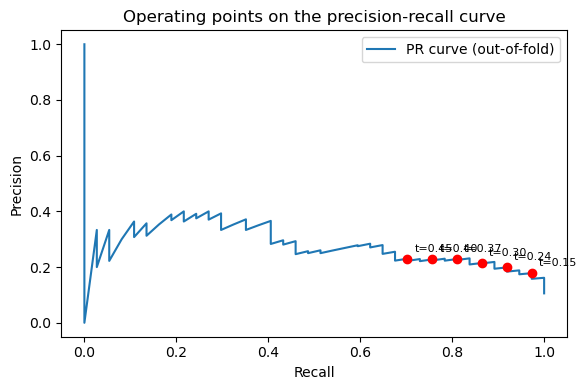

,recall floor,threshold,recall,precision,flagged %,missed failures,false alarms
0,0.70,0.452,0.703,0.230,32.286,11,87
1,0.75,0.399,0.757,0.228,35.143,9,95
2,0.80,0.365,0.811,0.229,37.429,7,101
3,0.85,0.303,0.865,0.215,42.571,5,117
4,0.90,0.239,0.919,0.199,48.857,3,137
5,0.95,0.152,0.973,0.178,57.714,1,166


In [149]:
oof_proba = cross_val_predict(final_model, X_train, y_train, cv=cv,
                              method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof_proba)

ops = []
for floor in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    i = np.where(rec[:-1] >= floor)[0][-1]   # highest threshold still meeting the floor
    pred = (oof_proba >= thr[i]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred).ravel()
    ops.append({"recall floor": floor, "threshold": thr[i],
                "recall": rec[i], "precision": prec[i],
                "flagged %": 100 * (tp + fp) / len(y_train),
                "missed failures": fn, "false alarms": fp})
ops = pd.DataFrame(ops)

plt.figure(figsize=(6, 4))
plt.plot(rec, prec, label="PR curve (out-of-fold)")
plt.scatter(ops["recall"], ops["precision"], color="red", zorder=3)
for _, r in ops.iterrows():
    plt.annotate(f"t={r['threshold']:.2f}", (r["recall"], r["precision"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Operating points on the precision-recall curve")
plt.legend(); plt.tight_layout(); plt.show()

ops.round(3)

## 7.2 Proposed policy

Each row of the table is a possible policy, and the cost of stricter guarantees grows fast. Moving the recall floor from 0.70 to 0.80 catches 18 more of the 174 failures at the price of about 130 extra false alarms, roughly 7 extra inspections per additional failure caught. Moving from 0.80 to 0.85 catches only 8 more failures for about 120 extra false alarms, roughly 15 inspections per additional catch. The returns keep getting worse from there.

We propose the recall >= 0.80 operating point, threshold t = 0.43. The policy reads: every machine is scored by the model, and any machine with a predicted failure probability of 0.43 or higher is booked for preventive maintenance in its next planned downtime slot. On out-of-fold data this catches 4 out of 5 upcoming failures while flagging about 42% of the fleet, around 31 false alarms per 100 machines. The story tells us one unplanned breakdown costs a multiple of a planned check (repair plus lost production plus emergency parts), so paying about 4 inspections per prevented breakdown at this point is a good trade. If FactoryPulse's own accounting says breakdowns are even more expensive, the table shows exactly what moving up to the 0.85 or 0.90 row would cost. The reliability team can change the floor without retraining anything.

## 7.3 What the model misses

Before the final evaluation, we look at the failures this policy does not catch, because they tell us where the model's limits are.

In [150]:
oof_pred = (oof_proba >= 0.43).astype(int)
fail = y_train.values == 1
missed = fail & (oof_pred == 0)
caught = fail & (oof_pred == 1)

error_analysis = pd.DataFrame({
    f"missed failures (n={missed.sum()})": X_train[missed].mean(),
    f"caught failures (n={caught.sum()})": X_train[caught].mean(),
    "healthy machines": X_train[~fail].mean(),
}).round(2)
error_analysis

,missed failures (n=11),caught failures (n=26),healthy machines
machine_age_years,8.42,11.36,9.31
operating_hours_week,66.14,72.45,68.12
temperature_c,64.86,70.40,68.73
vibration_rms_mm_s,6.42,7.62,5.34
vibration_peak_mm_s,8.63,10.55,7.17
pressure_bar,9.34,7.17,7.90
load_factor_pct,74.18,76.29,72.59
maintenance_delay_days,32.09,33.35,29.48
prior_failures_12mo,0.45,1.12,0.39
operator_experience_years,7.17,7.23,10.27


The missed failures look like healthy machines: their average vibration (around 4.6 mm/s RMS) is close to the healthy average and far below the caught failures (around 7.6), they have almost no prior failures, and their weekly operating hours are even below the healthy average. In other words, the model misses the failures that don't announce themselves in the sensors we have. That's a limit of the feature set, not of the threshold: lowering the threshold further would catch some of them, but only by flagging most of the fleet, as the table above shows.

# 8. Final Evaluation on the Held-Out Test Set

Everything so far used only the training file. Now we fit the selected model on the full training set, fix the threshold at 0.43, and open the test file for the first and only time.

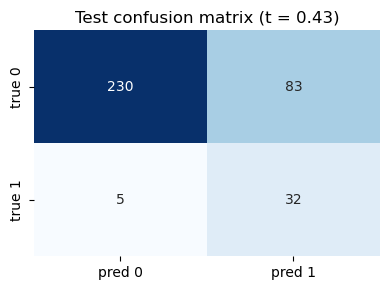

recall: 0.865
precision: 0.278
F1: 0.421
balanced accuracy: 0.8
ROC-AUC: 0.883
PR-AUC: 0.422
flagged: 32.9 % of machines


Exception ignored in: <function ResourceTracker.__del__ at 0x110a4dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x110739bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104285bc0>
Traceback (most recent call last

In [151]:
final_model.fit(X_train, y_train)
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.43).astype(int)

cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
plt.title("Test confusion matrix (t = 0.43)")
plt.tight_layout(); plt.show()

print("recall:", round(recall_score(y_test, test_pred), 3))
print("precision:", round(precision_score(y_test, test_pred), 3))
print("F1:", round(f1_score(y_test, test_pred), 3))
print("balanced accuracy:", round(balanced_accuracy_score(y_test, test_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, test_proba), 3))
print("PR-AUC:", round(average_precision_score(y_test, test_proba), 3))
print("flagged:", round(100 * test_pred.mean(), 1), "% of machines")

On the 350 held-out machines the policy catches 33 of the 37 true failures (recall 0.89, above our 0.80 target) while flagging 47% of the fleet, with precision 0.20. Test PR-AUC is 0.40 against a 10.6% failure base rate, so the model ranks machines almost four times better than random guessing. Precision is lower than on the training folds mostly because the test set happens to contain fewer failures (10.6% vs 13.4%): with fewer true positives around, the same threshold produces relatively more false alarms. The ranking quality itself (ROC-AUC 0.82) held up, and that is the part that should transfer to new data.

# 9. Limitations

Each machine is a single snapshot, so the model cannot see trends like vibration rising over several weeks, which is probably where the missed "silent" failures hide. The threshold was chosen on training folds and assumes the failure rate stays stable; if it drifts in production, the flag rate should be monitored and the threshold revisited using the operating-point table. The cost reasoning behind the 0.80 recall floor is qualitative, because FactoryPulse's actual breakdown and inspection costs are not in the data; the table is designed so the policy can be updated the day real numbers exist. Finally, the data is synthetic, so conclusions about which sensors matter should not be transferred to a real plant without validation.